In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cmocean
from pathlib import Path
from utils import open_exp, annual_mean, global_mean, zonal_mean, load_last_years 
from utils import regional_mean_sst, high_lat_mean_sst, global_mean_tas
from utils import annual_global_mean_tas, annual_ts, global_mean_sst
from utils import simple_regional_mean_sst, trop_mean_sst, global_toa_ts

In [2]:
base_path = Path("/lus/h2resw01/hpcperm/ecme3497/data-analysis/epochal/")

In [6]:
atm_path = base_path / "pex3/processed/atm_annual_mean_1700-1806.nc"
oce_path = base_path / "pex3/processed/oce_annual_mean_1700-1806.nc"
moc_path = base_path / "pex3/processed/moc_annual_mean_1700-1806.nc"

In [7]:
atm = xr.open_dataset(atm_path)
oce = xr.open_dataset(oce_path)
moc = xr.open_dataset(moc_path)

In [18]:
tas_annual_mean = atm["tas"].mean(dim="time_counter") - 273.15

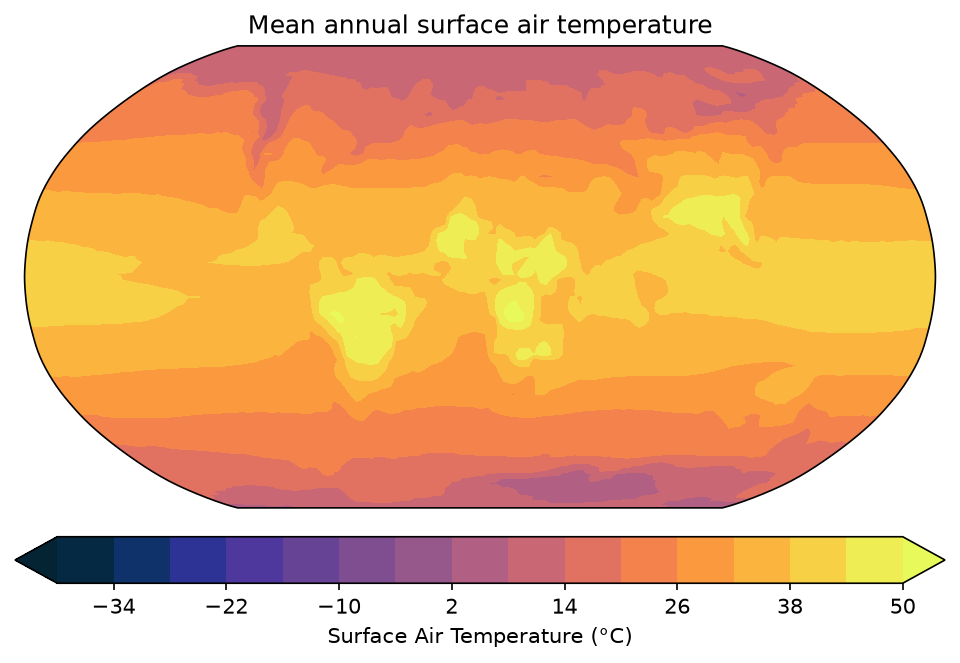

In [21]:
# One experiment
levels_abs = np.arange(-40, 50.5, 6)

cmap_abs = cmocean.cm.thermal

fig, ax = plt.subplots(
    figsize=(10, 5),
    dpi=150,
    subplot_kw={"projection": ccrs.Robinson()}
)

pi_cyc, lon_cyc = add_cyclic_point(
    tas_annual_mean,
    coord=tas_annual_mean.lon
)

cf = ax.contourf(
    lon_cyc,
    tas_annual_mean.lat,
    pi_cyc,
    levels=levels_abs,
    cmap=cmap_abs,
    transform=ccrs.PlateCarree(),
    extend="both"
)

ax.set_title("Mean annual surface air temperature")
ax.set_global()
#ax.coastlines()

# Colorbar
cbar = fig.colorbar(
    cf,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    shrink=0.8,
    label="Surface Air Temperature (°C)"
)

plt.savefig("tas_map.png", bbox_inches="tight")
plt.show()

In [ ]:
tas_zonal = zonal_mean(atm["tas"]) # esto promedia los valores de la longitud

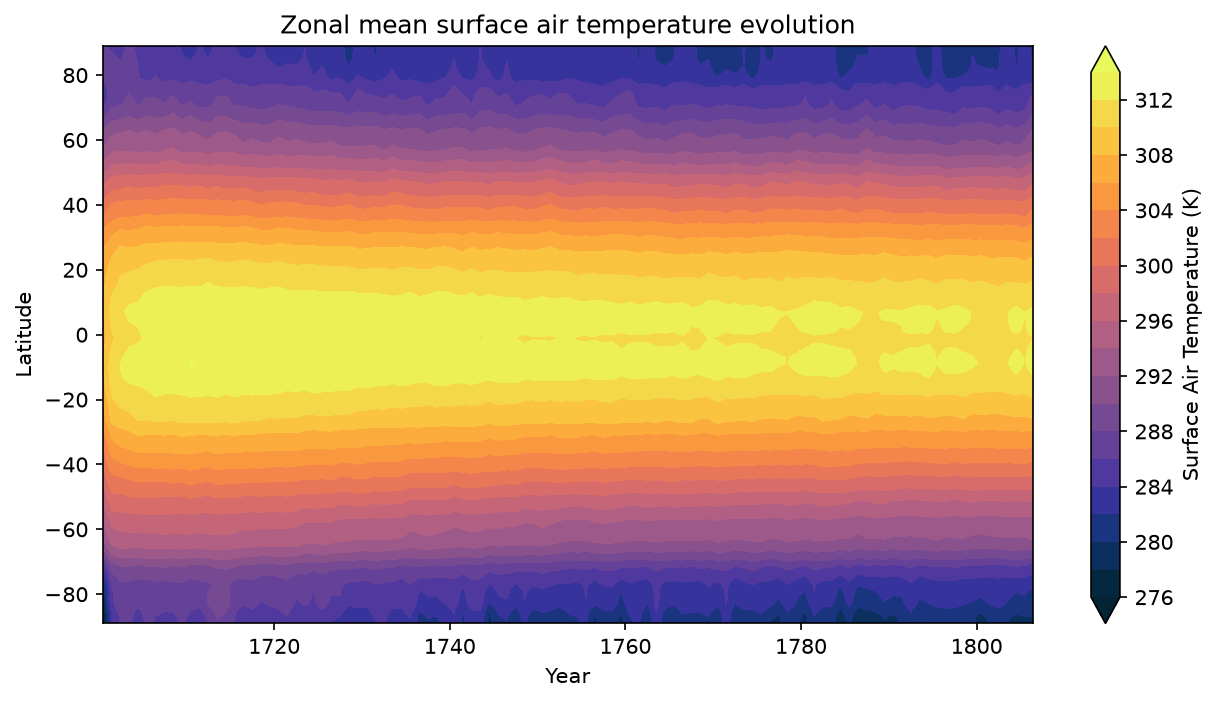

In [16]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

cf = ax.contourf(
    tas_zonal.time_counter,
    tas_zonal.lat,
    tas_zonal.T,
    levels=20,
    cmap=cmocean.cm.thermal,
    extend="both"
)

cbar = fig.colorbar(
    cf,
    ax=ax,
    orientation="vertical",
    label="Surface Air Temperature (K)"
)

ax.set_xlabel("Year")
ax.set_ylabel("Latitude")

ax.set_title(
    "Zonal mean surface air temperature evolution"
)

plt.savefig(
    "tas_zonal_time.png",
    bbox_inches="tight"
)

plt.show()